# Connectome-Statistics-Derived Initialization — Prototype Notebook
## Topic X1: Allen Mouse Brain Connectivity Atlas → Weight Initialization

### Research Question
Can weight distributions derived from **biological connectome statistics** (Allen Mouse Brain Connectivity Atlas, Oh et al. *Nature* 2014) preserve or improve class separability at initialization, compared to standard schemes (He, Xavier, Orthogonal)?

### What You Will Learn
1. What the Allen Mouse mesoscale connectome looks like as a weighted directed graph (~213 regions)
2. Its key statistical properties: **log-normal edge weights**, **scale-free degree distribution**, **rich-club hub structure**
3. How to translate those statistics into three novel initialization schemes
4. How to measure whether initialization affects the **geometric separability of class data** at each layer

### Connection to Existing Work
- Extends `../NN_Initialization/init_geometry_experiment_v2.ipynb`
- v2 key finding: at depth ≥ 10, only `orthogonal`/`xavier_uniform`/`he_normal` survive; `random_normal` collapses to NaN silhouette
- **New question**: Do connectome-derived inits outperform or differ qualitatively from standard ones?

### Structure
| Section | Content |
|---------|--------|
| 1 | Load the Allen Mouse Connectome (real or synthetic fallback) |
| 2 | Edge weight distribution — log-normal fit |
| 3 | Degree distribution + hub structure + null models |
| 4 | Define the three connectome-derived init schemes |
| 5 | MLP forward-pass geometry experiment (depth = 12) |
| 6 | Results + layer-by-layer separability curve |
| 7 | Research hypotheses for the full thesis |

## Cell 1 — Install Dependencies

Run this cell once if any of the packages are missing, then **restart the kernel**.

In [1]:
import subprocess, sys

PKGS = {
    'torch': 'torch',
    'torchvision': 'torchvision',
    'networkx': 'networkx',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
}
for mod, pkg in PKGS.items():
    try:
        __import__(mod)
        print(f'  ok  {pkg}')
    except ImportError:
        print(f'  installing {pkg}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)
        print(f'  done {pkg}')

print('\nRestart kernel if torch/networkx were just installed.')

  ok  torch
  ok  torchvision
  ok  networkx
  ok  seaborn
  ok  scikit-learn

Restart kernel if torch/networkx were just installed.


## Cell 2 — Imports, Configuration, Seeds

All hyperparameters live in `CONFIG`. No magic numbers below this cell.

Key parameters and their scientific justification:
- `n_regions = 213` — Allen Mouse mesoscale atlas, ipsilateral hemisphere (Oh et al. 2014)
- `connectome_density = 0.29` — ~29% of all region pairs have a measured projection
- `connectome_lognormal_mu = -3.5`, `sigma = 1.8` — log-normal parameters for normalized projection volumes; typical values from Allen connectivity studies
- `n_layers = 12` — v2 showed this is the depth where init differences become clear

In [2]:
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print('torch not available — run Cell 1 first')

try:
    import networkx as nx
    NX_AVAILABLE = True
except ImportError:
    NX_AVAILABLE = False

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 110
os.makedirs('./outputs', exist_ok=True)
os.makedirs('./data', exist_ok=True)

CONFIG = {
    'seed': 42,

    # Allen Mouse Brain Connectivity Atlas — mesoscale (Oh et al. 2014)
    'n_regions': 213,
    'connectome_density': 0.29,
    'connectome_lognormal_mu': -3.5,    # mean of log(normalized projection volume)
    'connectome_lognormal_sigma': 1.8,  # std  of log(normalized projection volume)
    'connectome_data_dir': './data',

    # MLP experiment
    'n_samples': 2000,
    'n_features': 64,
    'n_informative': 20,
    'hidden_dim': 256,
    'n_layers': 12,   # deep enough to expose differences (per v2 findings)

    # Metrics
    'pca_components': 50,
    'outputs_dir': './outputs',

    # Init scheme names
    'standard_inits':   ['he_normal', 'xavier_uniform', 'orthogonal', 'random_normal'],
    'connectome_inits': ['connectome_marginal', 'connectome_lognormal', 'connectome_degree'],
}


def set_seeds(seed: int) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


set_seeds(CONFIG['seed'])
DEVICE = torch.device('cuda' if TORCH_AVAILABLE and torch.cuda.is_available() else 'cpu') if TORCH_AVAILABLE else None

print(f'torch: {TORCH_AVAILABLE} | networkx: {NX_AVAILABLE} | device: {DEVICE}')
print(f'seed: {CONFIG["seed"]} | depth: {CONFIG["n_layers"]} layers')
print('CONFIG loaded')

torch: True | networkx: True | device: cpu
seed: 42 | depth: 12 layers
CONFIG loaded


## Section 1 — Allen Mouse Brain Connectivity Atlas

### Background
The Allen Mouse Brain Connectivity Atlas (Oh et al., *Nature* 508:207–214, 2014) maps the entire mouse brain at mesoscale resolution using anterograde viral tracers. The result is a **directed weighted graph** where:
- **Nodes** = brain regions (~213 ipsilateral structures)
- **Edges** = measured axonal projections between regions
- **Edge weights** = normalized projection volume (fraction of target region covered)

### Key statistical properties relevant to initialization
| Property | Value (Oh et al. 2014) | Implication for init |
|----------|----------------------|--------------------|
| Connection density | ~29% | Sparse, not all-to-all |
| Edge weight distribution | Log-normal | Heavy tail — a few weights much larger than rest |
| Degree distribution | Power-law (scale-free) | Hub regions have disproportionately many connections |
| Rich-club | Significant | Hubs connect preferentially to each other |

### Why standard inits ignore all of this
He/Xavier assume: all weights i.i.d. from the same distribution, uniform variance across neurons, Gaussian shape. The connectome violates all three: neurons have heterogeneous connectivity, weights are heavy-tailed, hubs break uniformity.

### Data loading strategy
This cell tries `allensdk` first. If unavailable, it generates a **synthetic connectome** with identical statistical properties (log-normal weights, scale-free degrees, ~29% density). The statistical analysis and init schemes work identically for both.

In [3]:
def _generate_synthetic_connectome(config: dict) -> tuple:
    """Generate a synthetic square region×region connectome.

    Matches three properties of the Allen Mouse Brain mesoscale connectome:
      1. Scale-free out-degree (power-law, gamma=2.3)
      2. Log-normal edge weights
      3. Target density (config['connectome_density'])

    Returns:
        W: (N, N) directed weight matrix, W[i, j] = i -> j strength
        region_names: list of N region name strings
    """
    rng = np.random.default_rng(config['seed'])
    N = config['n_regions']
    density = config['connectome_density']
    mu = config['connectome_lognormal_mu']
    sigma = config['connectome_lognormal_sigma']

    gamma = 2.3
    u = rng.uniform(0, 1, N)
    k_raw = np.round((1 - u) ** (-1.0 / (gamma - 1))).astype(int)
    k = np.clip(k_raw, 1, N - 1)
    k_out = k.astype(float)
    k_in = rng.permutation(k).astype(float)
    P = np.outer(k_out, k_in)
    P /= P.sum() / (N * N * density)
    P = np.clip(P, 0, 0.95)
    np.fill_diagonal(P, 0)

    A = (rng.random((N, N)) < P).astype(float)
    n_edges = int(A.sum())
    W = A.copy()
    W[A > 0] = rng.lognormal(mu, sigma, n_edges)
    region_names = [f'R{i:03d}' for i in range(N)]
    return W, region_names


def _load_allen_sdk(config: dict) -> tuple:
    """Load the Allen Mouse Brain mesoscale connectome as a square region×region matrix.

    Pipeline:
      1. Fetch the experiment × target-region matrix of normalized_projection_volume.
      2. Aggregate experiments by primary_injection_structure → one row per source
         region (mean across injection replicates of the same region).
      3. Restrict to the SQUARE submatrix of regions appearing both as source and
         as target, yielding a directed region×region connectome.
      4. Threshold by quantile to match the published density (~29%, Oh et al.
         2014), discarding the noise floor of tiny near-zero projection volumes.

    Returns:
        W: (N, N) directed connectome weight matrix
        region_names: list of N region acronyms
    """
    from allensdk.core.mouse_connectivity_cache import MouseConnectivityCache

    mcc = MouseConnectivityCache(
        manifest_file=os.path.join(config['connectome_data_dir'], 'manifest.json')
    )
    structure_tree = mcc.get_structure_tree()
    structures = structure_tree.get_structures_by_set_id(
        MouseConnectivityCache.DEFAULT_STRUCTURE_SET_IDS
    )
    structure_ids = [s['id'] for s in structures]
    id_to_acronym = {s['id']: s['acronym'] for s in structures}

    experiments = mcc.get_experiments(cre=False)
    exp_ids = [e['id'] for e in experiments]
    src_id_per_exp = [e['primary_injection_structure'] for e in experiments]

    pm = mcc.get_projection_matrix(
        experiment_ids=exp_ids,
        projection_structure_ids=structure_ids,
        hemisphere_ids=[2],
        parameter='normalized_projection_volume',
    )
    raw_matrix = np.asarray(pm['matrix'], dtype=float)  # (n_exp, n_target)
    raw_matrix[raw_matrix < 0] = 0

    # Step 2 — aggregate experiments by source region (mean across replicates)
    unique_src_ids = sorted(set(src_id_per_exp))
    src_id_to_row = {sid: i for i, sid in enumerate(unique_src_ids)}
    W_src_tgt = np.zeros((len(unique_src_ids), len(structure_ids)), dtype=float)
    for sid, row in src_id_to_row.items():
        exp_rows = [j for j, sj in enumerate(src_id_per_exp) if sj == sid]
        W_src_tgt[row, :] = raw_matrix[exp_rows, :].mean(axis=0)

    # Step 3 — restrict to square submatrix (source ∩ target)
    tgt_id_to_col = {sid: i for i, sid in enumerate(structure_ids)}
    common_ids = [sid for sid in unique_src_ids if sid in tgt_id_to_col]
    src_rows = [src_id_to_row[sid] for sid in common_ids]
    tgt_cols = [tgt_id_to_col[sid] for sid in common_ids]
    W_region = W_src_tgt[np.ix_(src_rows, tgt_cols)].copy()
    np.fill_diagonal(W_region, 0)

    # Step 4 — threshold to target density (Oh et al. 2014: ~29%)
    target_density = config['connectome_density']
    n_off_diag = W_region.size - W_region.shape[0]
    target_edges = max(1, int(target_density * n_off_diag))
    nonzero = W_region[W_region > 0]
    if len(nonzero) > target_edges:
        threshold = float(np.partition(nonzero, -target_edges)[-target_edges])
        W_region[W_region < threshold] = 0.0

    region_names = [id_to_acronym[sid] for sid in common_ids]
    return W_region, region_names


def load_connectome(config: dict) -> tuple:
    """Load the Allen Mouse Brain mesoscale connectome as a square region×region matrix.

    Tries the AllenSDK first; falls back to a synthetic connectome with matching
    statistical properties if the SDK is unavailable.

    Returns:
        W:            (N, N) directed connectome weight matrix
        region_names: list of N region acronym strings
        source:       'allen_sdk' or 'synthetic'
    """
    try:
        W, names = _load_allen_sdk(config)
        return W, names, 'allen_sdk'
    except Exception as exc:
        print(f'allensdk unavailable ({type(exc).__name__}: {exc}). Using synthetic connectome.')
        W, names = _generate_synthetic_connectome(config)
        return W, names, 'synthetic'


# --- Load and extract basic graph properties ---
set_seeds(CONFIG['seed'])
W_connectome, region_names, connectome_source = load_connectome(CONFIG)

N_REGIONS = W_connectome.shape[0]
N_EDGES   = int((W_connectome > 0).sum())
DENSITY   = N_EDGES / (N_REGIONS * (N_REGIONS - 1))  # off-diagonal density

# in_deg    = # incoming edges per target neuron (used by connectome_degree init)
# out_deg   = # outgoing edges per source neuron
# total_deg = in_deg + out_deg, used for rich-club thresholding
in_deg    = (W_connectome > 0).sum(axis=0).astype(float)
out_deg   = (W_connectome > 0).sum(axis=1).astype(float)
total_deg = in_deg + out_deg

hub_threshold = np.percentile(in_deg, 90)
is_hub = in_deg >= hub_threshold

is_square = True  # load_connectome always returns a square matrix

print(f'Connectome loaded  (source: {connectome_source})')
print(f'  Regions:  {N_REGIONS}')
print(f'  Edges:    {N_EDGES}')
print(f'  Density:  {DENSITY:.3f}  (off-diagonal; target was {CONFIG["connectome_density"]:.2f})')
print(f'  Hubs:     {is_hub.sum()} regions (top 10% by in-degree)')


Connectome loaded  (source: allen_sdk)
  Regions:  157
  Edges:    7102
  Density:  0.290  (off-diagonal; target was 0.29)
  Hubs:     17 regions (top 10% by in-degree)


## Cell 3b — Compute Edge-Weight Statistics

Extract `edge_weights`, `log_w`, `MU_LW`, `SIGMA_LW` from the loaded connectome.
These variables are required by Cell 4 (adjacency plot) and Section 2 (edge-weight deep-dive).

In [4]:
edge_weights = W_connectome[W_connectome > 0].flatten()
log_w = np.log(edge_weights)
MU_LW, SIGMA_LW = float(log_w.mean()), float(log_w.std())

print(f'Edge weights: {len(edge_weights):,} non-zero entries')
print(f'log(w): mean={MU_LW:.3f}, std={SIGMA_LW:.3f}  (bell-shaped on log-scale => log-normal)')

Edge weights: 7,102 non-zero entries
log(w): mean=-2.679, std=1.353  (bell-shaped on log-scale => log-normal)


## Cell 4 — Visualize the Connectivity Matrix

Three views of the connectome:
1. **Adjacency matrix** sorted by out-degree — reveals block structure (anatomical modules)
2. **Degree distribution** — should be heavy-tailed, not Poisson
3. **Edge weight histogram** — should be log-normal (bell-shaped on log scale)

The `log1p` transform is applied to the adjacency matrix because edge weights span many orders of magnitude.

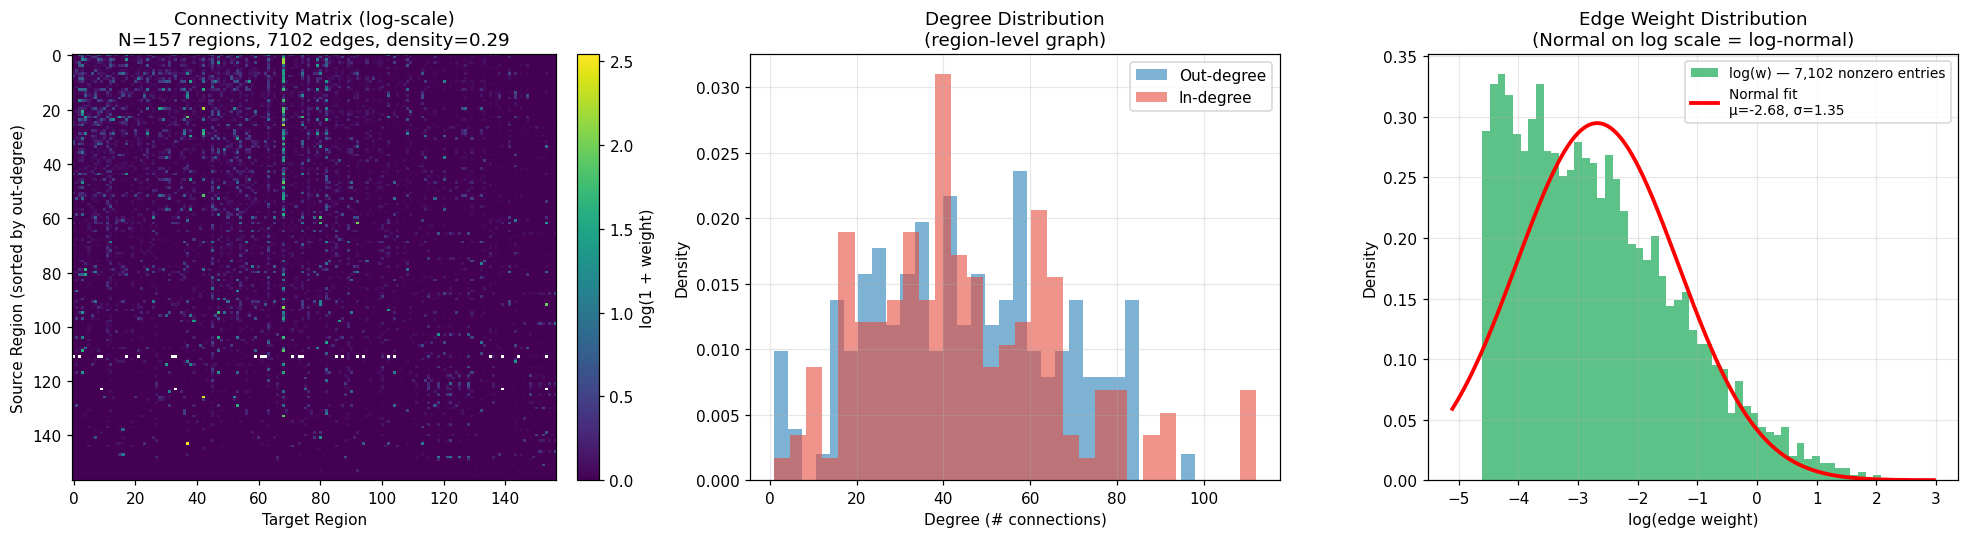

Saved c1_connectome_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

is_square = W_connectome.shape[0] == W_connectome.shape[1]

# --- Plot 1: Connectivity / Projection matrix ---
ax = axes[0]

if is_square:
    # region x region case
    sort_idx = np.argsort(out_deg)[::-1]
    W_sorted = np.log1p(W_connectome[np.ix_(sort_idx, sort_idx)])

    xlabel = "Target Region"
    ylabel = "Source Region (sorted by out-degree)"
    matrix_title = (
        f"Connectivity Matrix (log-scale)\n"
        f"N={W_connectome.shape[0]} regions, {N_EDGES} edges, density={DENSITY:.2f}"
    )

else:
    # experiment x target_region case
    row_sort_idx = np.argsort(out_deg)[::-1]
    col_sort_idx = np.argsort(in_deg)[::-1]

    W_sorted = np.log1p(W_connectome[np.ix_(row_sort_idx, col_sort_idx)])

    xlabel = "Target Region (sorted by projection frequency)"
    ylabel = "Injection Experiment (sorted by outgoing projections)"
    matrix_title = (
        f"Projection Matrix (log-scale)\n"
        f"{W_connectome.shape[0]} experiments × {W_connectome.shape[1]} target regions, "
        f"density={DENSITY:.2f}"
    )

im = ax.imshow(W_sorted, aspect="auto", cmap="viridis", interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="log(1 + weight)")
ax.set_title(matrix_title)
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)


# --- Plot 2: Degree / projection-count distribution ---
ax = axes[1]

if is_square:
    ax.hist(out_deg, bins=30, color="#2980B9", alpha=0.6, label="Out-degree", density=True)
    ax.hist(in_deg,  bins=30, color="#E74C3C", alpha=0.6, label="In-degree",  density=True)
    ax.set_title("Degree Distribution\n(region-level graph)")
    ax.set_xlabel("Degree (# connections)")
else:
    ax.hist(out_deg, bins=30, color="#2980B9", alpha=0.6, label="Experiment out-count", density=True)
    ax.hist(in_deg,  bins=30, color="#E74C3C", alpha=0.6, label="Target region in-count", density=True)
    ax.set_title("Projection Count Distribution\n(experiment × target matrix)")
    ax.set_xlabel("# nonzero projections")

ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)


# --- Plot 3: Edge weight distribution ---
ax = axes[2]

ax.hist(
    log_w,
    bins=55,
    color="#27AE60",
    alpha=0.75,
    density=True,
    label=f"log(w) — {len(edge_weights):,} nonzero entries"
)

x_fit = np.linspace(log_w.min() - 0.5, log_w.max() + 0.5, 300)

ax.plot(
    x_fit,
    stats.norm.pdf(x_fit, MU_LW, SIGMA_LW),
    "r-",
    linewidth=2.5,
    label=f"Normal fit\nμ={MU_LW:.2f}, σ={SIGMA_LW:.2f}"
)

ax.set_title("Edge Weight Distribution\n(Normal on log scale = log-normal)")
ax.set_xlabel("log(edge weight)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./outputs/c1_connectome_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved c1_connectome_overview.png")

## Section 2 — Edge Weight Distribution Deep Dive

### Why the log-normal shape matters for initialization

Standard He init samples from `N(0, 2/fan_in)` — a **Gaussian**. Weight magnitudes cluster tightly around zero.

The connectome has a **log-normal** distribution: `log|w| ~ N(μ, σ²)`. This means:
- Most weights are very small (log-scale mean ≈ e^μ)
- A few weights are very large (the heavy tail)
- Coefficient of variation CV >> 1

This heavy tail is the key biological signal we want to test.

### Q-Q plot
A Q-Q plot against Normal should be approximately **linear** if log(w) is truly Normal (i.e., w is log-normal). Deviations indicate how the empirical distribution differs from a perfect log-normal.

### Direct comparison
The third panel shows `|He init weights|` vs `|connectome weights|` on log scale — both normalized to the same standard deviation to isolate the **shape** difference.

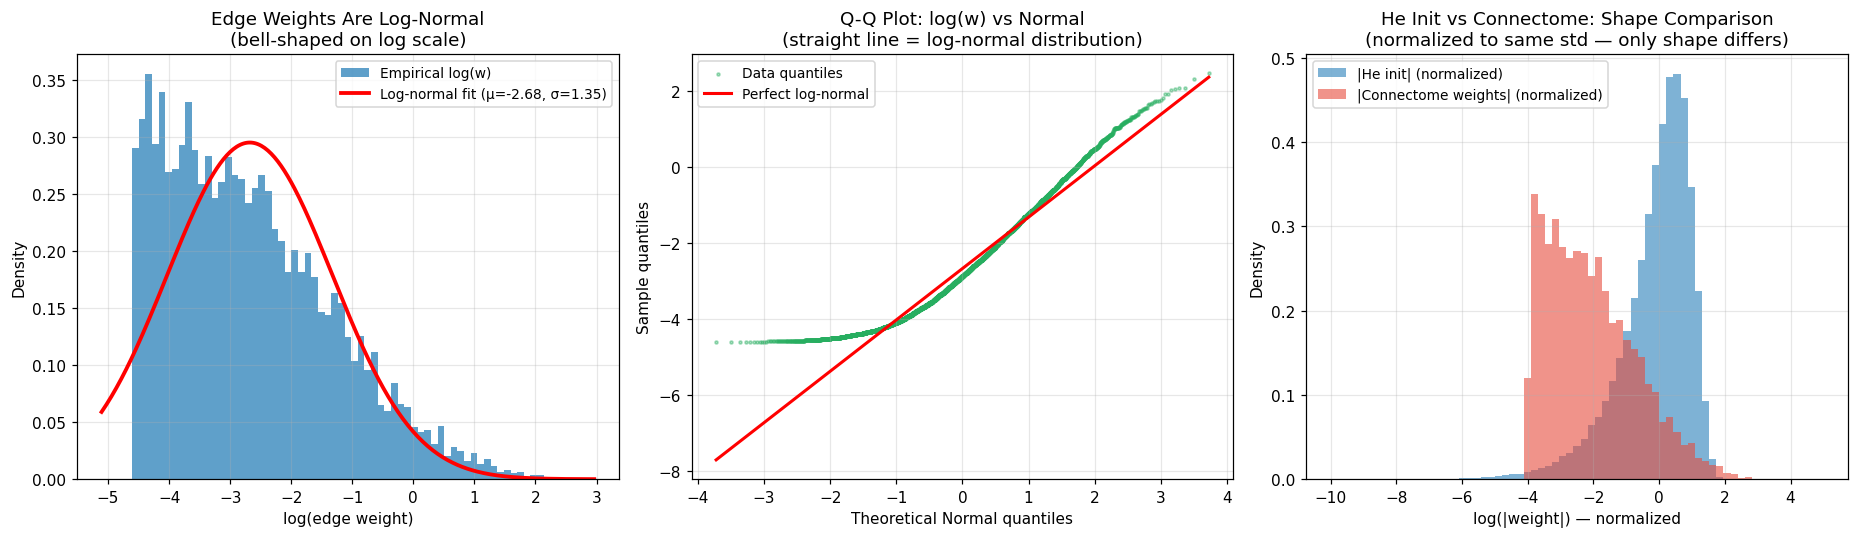

Saved c2_edge_weight_analysis.png
  KS test log(w) vs Normal: p=0.0000  (p<0.05 rejects normality; with N=7,102 even tiny deviations are detected — inspect Q-Q plot visually)
  Key: connectome weights have a much heavier tail than He init weights


In [6]:
x_fit = np.linspace(log_w.min() - 0.5, log_w.max() + 0.5, 300)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Plot 1: Detailed log-weight histogram ---
ax = axes[0]
ax.hist(log_w, bins=65, color='#2980B9', alpha=0.75, density=True,
        label='Empirical log(w)')
ax.plot(x_fit, stats.norm.pdf(x_fit, MU_LW, SIGMA_LW), 'r-', linewidth=2.5,
        label=f'Log-normal fit (\u03bc={MU_LW:.2f}, \u03c3={SIGMA_LW:.2f})')
# Overlay a Gaussian with same mean/std on the raw weights for comparison
ax.set_title('Edge Weights Are Log-Normal\n(bell-shaped on log scale)')
ax.set_xlabel('log(edge weight)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Plot 2: Q-Q plot ---
ax = axes[1]
os_m, os_r = stats.probplot(log_w, dist='norm', fit=False)
ax.scatter(os_m, os_r, s=4, alpha=0.4, color='#27AE60', label='Data quantiles')
ref_x = np.array([os_m.min(), os_m.max()])
ax.plot(ref_x, MU_LW + SIGMA_LW * ref_x, 'r-', linewidth=2, label='Perfect log-normal')
ax.set_title('Q-Q Plot: log(w) vs Normal\n(straight line = log-normal distribution)')
ax.set_xlabel('Theoretical Normal quantiles')
ax.set_ylabel('Sample quantiles')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Plot 3: He weights vs connectome weights (shape comparison) ---
ax = axes[2]
fan_in_demo = 256
he_magnitudes = np.abs(np.random.normal(0, np.sqrt(2.0 / fan_in_demo), 80_000))
conn_magnitudes = edge_weights.copy()
# Normalize to same std for fair shape comparison
he_normed = he_magnitudes / he_magnitudes.std()
conn_normed = conn_magnitudes / conn_magnitudes.std()
bins = np.linspace(-10, 5, 70)
ax.hist(np.log(he_normed + 1e-12),   bins=bins, alpha=0.6, density=True,
        color='#2980B9', label='|He init| (normalized)')
ax.hist(np.log(conn_normed + 1e-12), bins=bins, alpha=0.6, density=True,
        color='#E74C3C', label='|Connectome weights| (normalized)')
ax.set_title('He Init vs Connectome: Shape Comparison\n(normalized to same std — only shape differs)')
ax.set_xlabel('log(|weight|) — normalized')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# KS test: is log(w) Gaussian?
_, p_ks = stats.kstest(log_w, 'norm', args=(MU_LW, SIGMA_LW))

plt.tight_layout()
plt.savefig('./outputs/c2_edge_weight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved c2_edge_weight_analysis.png')
print(f'  KS test log(w) vs Normal: p={p_ks:.4f}  (p<0.05 rejects normality; with N={len(log_w):,} even tiny deviations are detected — inspect Q-Q plot visually)')
print(f'  Key: connectome weights have a much heavier tail than He init weights')

## Section 3 — Degree Distribution, Hub Structure, and Null Models

### Scale-free degree distribution
Brain networks show `P(k) ∝ k^{-γ}` (power-law), meaning a few hub regions have very high degree. This contrasts with an **Erdős-Rényi (ER)** random graph where `P(k)` is Poisson (symmetric around the mean).

### Rich-club coefficient
`φ(k) = 2E_k / (N_k(N_k - 1))`
- `N_k` = nodes with degree > k
- `E_k` = edges between those nodes
- `φ(k) > φ_random(k)` means high-degree nodes connect preferentially to each other — the "rich-club" effect

### Why this matters for initialization
The `connectome_degree` init scheme uses the **in-degree distribution** to assign per-neuron weight scales:
- Hub neurons (high in-degree) → wider weight distribution (more signal coming in)
- Peripheral neurons (low in-degree) → narrower weight distribution

This heterogeneity across neurons is the key difference from He init (which uses the same scale everywhere). The null models (ER, scale-free) let us ask: is the connectome's degree structure special, or is any heavy-tailed graph equivalent?

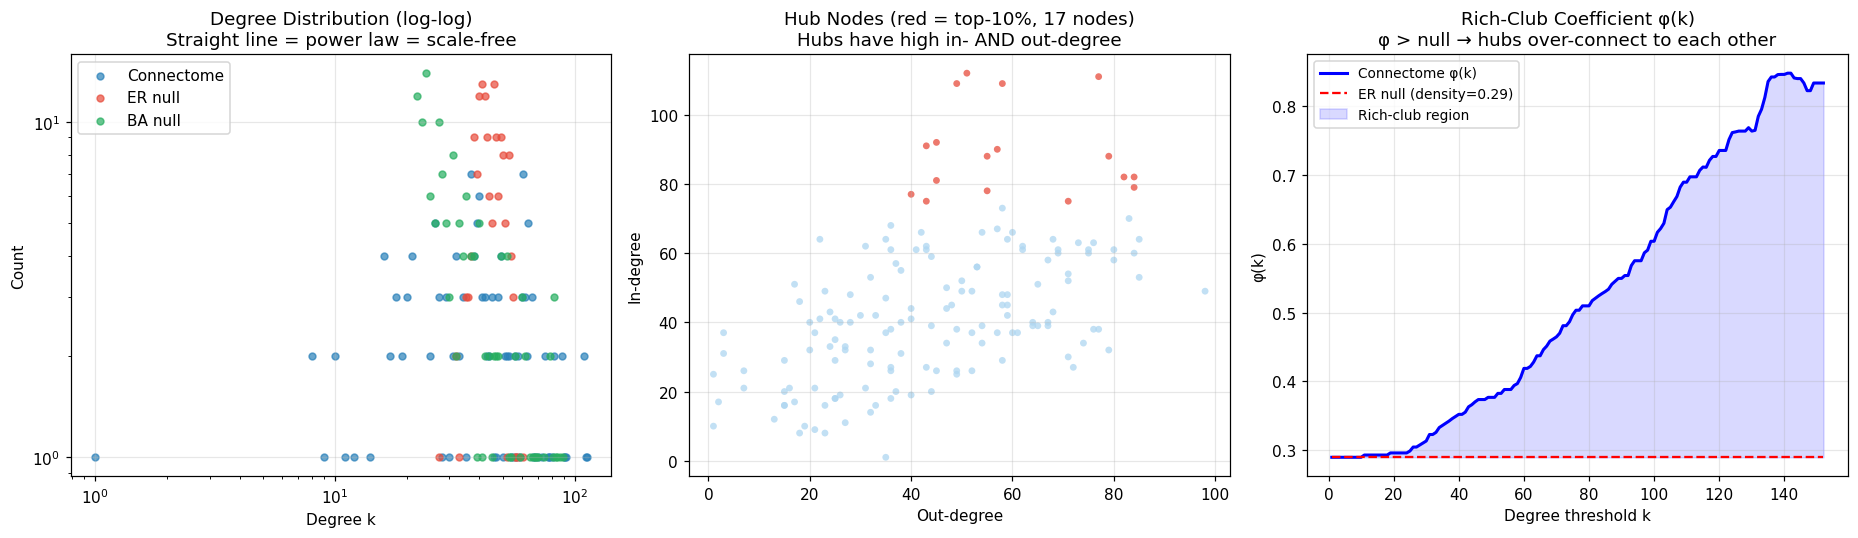

Saved c3_degree_hub_nullmodels.png
  In-degree stats: mean=45.2, std=22.5, max=112
  ER in-degree: mean=44.5, std=5.9
  Rich-club at k=median: phi=0.503 vs null=0.290


In [7]:
# Generate null models for comparison
rng_null = np.random.default_rng(CONFIG['seed'] + 99)

# Erdos-Renyi: same N and density, edges placed uniformly
A_er = (rng_null.random((N_REGIONS, N_REGIONS)) < DENSITY).astype(float)
np.fill_diagonal(A_er, 0)
er_in_deg = A_er.sum(axis=0)

# Scale-free: Barabasi-Albert via networkx (or manual power-law)
if NX_AVAILABLE:
    G_ba = nx.barabasi_albert_graph(N_REGIONS, m=max(1, int(DENSITY * N_REGIONS / 2)),
                                    seed=CONFIG['seed'])
    ba_in_deg = np.array([G_ba.degree(i) for i in range(N_REGIONS)], dtype=float)
else:
    # Manual power-law approximation
    u_ba = rng_null.uniform(0, 1, N_REGIONS)
    ba_in_deg = np.clip(np.round((1 - u_ba) ** (-1.0 / 1.3)), 1, N_REGIONS - 1).astype(float)


fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Plot 1: Degree distributions on log-log scale ---
ax = axes[0]
for deg_arr, label, color in [
    (in_deg,               'Connectome', '#2980B9'),
    (er_in_deg,            'ER null',    '#E74C3C'),
    (ba_in_deg,            'BA null',    '#27AE60'),
]:
    counts, edges_ = np.histogram(deg_arr, bins=np.arange(0.5, deg_arr.max() + 1.5))
    centers = (edges_[:-1] + edges_[1:]) / 2
    ok = counts > 0
    ax.scatter(centers[ok], counts[ok], s=20, alpha=0.7, color=color, label=label)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Degree Distribution (log-log)\nStraight line = power law = scale-free')
ax.set_xlabel('Degree k')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)

# --- Plot 2: Hub nodes scatter ───────────────────────────────────
ax = axes[1]
hub_colors = ['#E74C3C' if h else '#AED6F1' for h in is_hub]
if W_connectome.shape[0] == W_connectome.shape[1]:
    # Square matrix: scatter source out-degree vs target in-degree
    ax.scatter(out_deg, in_deg, c=hub_colors, s=20, alpha=0.75, edgecolors='none')
    ax.set_title(f'Hub Nodes (red = top-10%, {is_hub.sum()} nodes)\nHubs have high in- AND out-degree')
    ax.set_xlabel('Out-degree')
    ax.set_ylabel('In-degree')
else:
    # Non-square: out_deg (498 experiments) and in_deg (316 regions) differ in length.
    # Show ranked in-degree (target region projection frequency) instead.
    sorted_idx = np.argsort(in_deg)[::-1]
    colors_sorted = ['#E74C3C' if is_hub[i] else '#AED6F1' for i in sorted_idx]
    ax.bar(range(len(in_deg)), in_deg[sorted_idx], color=colors_sorted, width=1.0, edgecolor='none')
    ax.set_title(f'Hub Target Regions (red = top-10%, {is_hub.sum()} regions)\nRanked by projection frequency')
    ax.set_xlabel('Target region rank')
    ax.set_ylabel('In-projection count')
ax.grid(alpha=0.3)

# --- Plot 3: Rich-club coefficient (square region×region matrix only) ---
ax = axes[2]
if W_connectome.shape[0] == W_connectome.shape[1]:
    k_vals = np.arange(1, int(np.percentile(total_deg, 95)))
    phi_real = []
    for k_thresh in k_vals:
        rich = total_deg > k_thresh
        n_r = rich.sum()
        if n_r < 2:
            phi_real.append(np.nan)
            continue
        e_r = (W_connectome[np.ix_(rich, rich)] > 0).sum()
        phi_real.append(e_r / (n_r * (n_r - 1)))
    phi_real = np.array(phi_real)
    phi_null = np.full_like(phi_real, DENSITY)
    valid = ~np.isnan(phi_real)
    ax.plot(k_vals[valid], phi_real[valid], 'b-', linewidth=2, label='Connectome \u03c6(k)')
    ax.plot(k_vals[valid], phi_null[valid], 'r--', linewidth=1.5, label=f'ER null (density={DENSITY:.2f})')
    ax.fill_between(k_vals[valid], phi_null[valid], phi_real[valid],
                    where=(phi_real[valid] > phi_null[valid]),
                    alpha=0.15, color='blue', label='Rich-club region')
    ax.set_title('Rich-Club Coefficient \u03c6(k)\n\u03c6 > null \u2192 hubs over-connect to each other')
else:
    ax.text(0.5, 0.5,
            'Rich-club requires a square region\u00d7region matrix.\n'
            'Not available for the Allen SDK experiment\u00d7region matrix.\n'
            'Use synthetic connectome or aggregate by source region.',
            ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
    ax.set_title('Rich-Club Coefficient\n(requires square region\u00d7region matrix)')
ax.set_xlabel('Degree threshold k')
ax.set_ylabel('\u03c6(k)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/c3_degree_hub_nullmodels.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved c3_degree_hub_nullmodels.png')
print(f'  In-degree stats: mean={in_deg.mean():.1f}, std={in_deg.std():.1f}, max={in_deg.max():.0f}')
print(f'  ER in-degree: mean={er_in_deg.mean():.1f}, std={er_in_deg.std():.1f}')
if W_connectome.shape[0] == W_connectome.shape[1]:
    print(f'  Rich-club at k=median: phi={phi_real[len(k_vals)//2]:.3f} vs null={DENSITY:.3f}')
else:
    print('  Rich-club: skipped (non-square matrix — requires region×region connectivity)')

## Section 4 — Translating Connectome Statistics into Init Schemes

### The three proposed schemes

**Scheme 1 — `connectome_marginal`**
Sample weight *magnitudes* from the **empirical connectome distribution** (the actual non-zero edge weights, normalized to unit std), then apply random ±1 signs and scale to match He variance.
```
|w| ~ Empirical(connectome weights / std(connectome weights)) * sqrt(2/fan_in)
sign(w) ~ Bernoulli(0.5)
```
*Property*: exact heavy-tail shape preserved; a few weights will be much larger than typical He weights.

**Scheme 2 — `connectome_lognormal`**
Fit a log-normal distribution to connectome weights, sample from the parametric model.
```
|w| ~ LogNormal(μ_fit, σ_fit) scaled so E[w²] = 2/fan_in
```
*Property*: parametric version of Scheme 1; allows extrapolation; fully characterized by two numbers.

**Scheme 3 — `connectome_degree`**
Draw each neuron's weight *scale* from the connectome's **in-degree distribution**:
```
d_j ~ Empirical(in_degree / mean_in_degree)   # one per output neuron j
w_j ~ N(0, sqrt(2/fan_in) * sqrt(d_j))        # hub neurons get wider distribution
```
*Property*: breaks uniform-variance assumption; hub neurons (high d_j) have larger weights.

### Variance matching constraint
All three schemes are scaled so `E[w²] = 2/fan_in` (same as He init). This isolates the effect of **shape and heterogeneity** from the effect of scale — a key experimental control.

### Demo
The plot below shows the actual weight distribution for each scheme applied to a 256→256 layer, confirming variance matching.

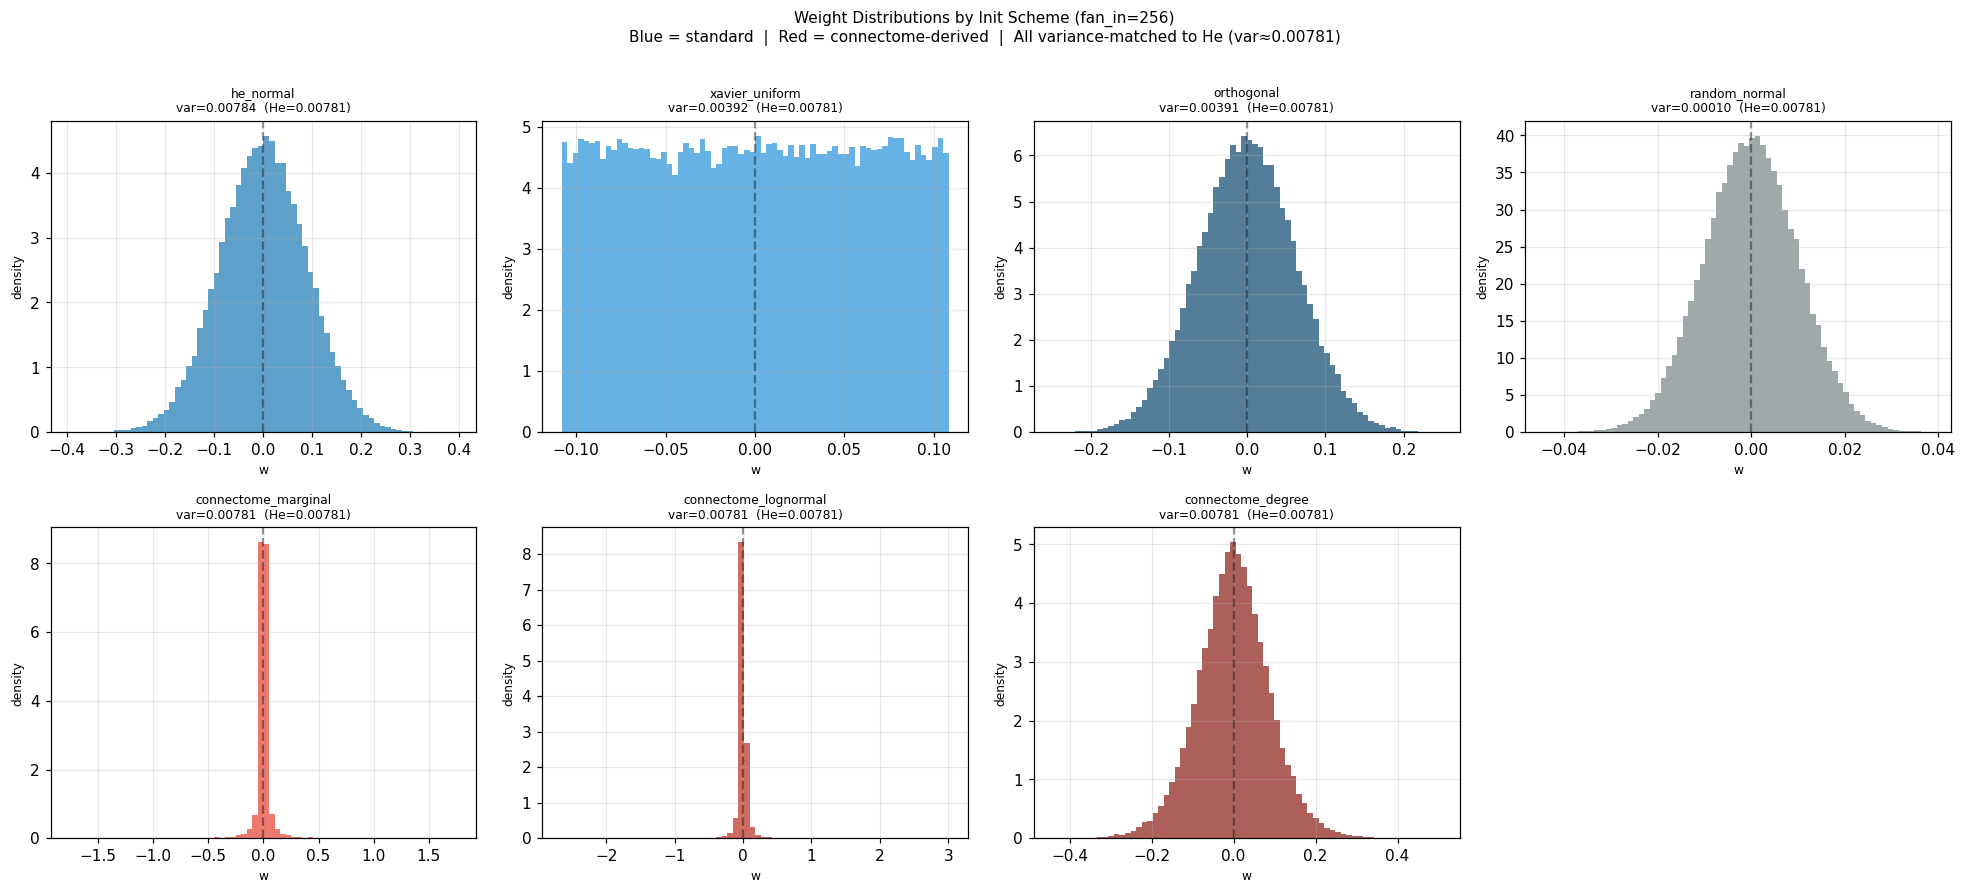

Saved c4_init_weight_distributions.png
All connectome inits are variance-matched to He empirically. Only shape/heterogeneity differs.


In [8]:
def _get_connectome_stats(W: np.ndarray) -> dict:
    """Extract initialization statistics from a connectome weight matrix.

    Args:
        W: (N, N) weighted adjacency matrix

    Returns:
        dict with keys used by apply_init:
        - weights_normed: unit-std normalized non-zero weights (empirical sampling pool)
        - mu_lw, sigma_lw: log-normal fit parameters of the non-zero weights
        - in_degree_ratio: per-region in-degree divided by mean (mean=1)
    """
    w_pos = W[W > 0].flatten()
    lw = np.log(w_pos)
    in_d = (W > 0).sum(axis=0).astype(float)
    return {
        'weights_normed':  w_pos / w_pos.std(),
        'mu_lw':           float(lw.mean()),
        'sigma_lw':        float(lw.std()),
        'in_degree_ratio': in_d / in_d.mean(),
    }


def _match_he_variance_empirical(w: np.ndarray, he_std: float) -> np.ndarray:
    """Rescale weight tensor so its empirical std matches He init.

    For heavy-tailed distributions (e.g. log-normal with sigma >> 1) the
    theoretical second-moment formula gives the right variance in expectation,
    but on the finite sample size of one layer the variance is dominated by
    extreme outliers that rarely appear. Empirical rescaling guarantees the
    layer-level variance is correct regardless of distribution shape.
    """
    cur_std = float(w.std())
    if cur_std < 1e-12:
        return w
    return w * (he_std / cur_std)


def apply_init(model, scheme: str, conn_stats: dict) -> None:
    """Apply a named initialization scheme to all Linear layers in model.

    All connectome schemes are variance-matched to He init so that
    Var(w) = 2/fan_in for every layer, isolating shape effects.
    Variance matching is done empirically (per-tensor std rescaling) to
    handle heavy-tail distributions correctly.

    Args:
        model: nn.Module with Linear layers
        scheme: name from CONFIG['standard_inits'] or CONFIG['connectome_inits']
        conn_stats: output of _get_connectome_stats
    """
    for m in model.modules():
        if not isinstance(m, nn.Linear):
            continue
        fan_in  = m.weight.shape[1]
        fan_out = m.weight.shape[0]
        shape   = (fan_out, fan_in)
        he_std  = float(np.sqrt(2.0 / fan_in))

        if scheme == 'he_normal':
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')

        elif scheme == 'xavier_uniform':
            nn.init.xavier_uniform_(m.weight)

        elif scheme == 'orthogonal':
            nn.init.orthogonal_(m.weight)

        elif scheme == 'random_normal':
            nn.init.normal_(m.weight, 0, 0.01)

        elif scheme == 'connectome_marginal':
            # Sample magnitudes from the empirical (non-zero) edge weights,
            # apply random signs, then rescale to match He std empirically.
            w_n = conn_stats['weights_normed']
            idx = np.random.randint(0, len(w_n), size=fan_out * fan_in)
            magnitudes = w_n[idx].reshape(shape)
            signs = np.random.choice([-1.0, 1.0], size=shape)
            w = magnitudes * signs
            w = _match_he_variance_empirical(w, he_std)
            m.weight.data = torch.FloatTensor(w.astype(np.float32))

        elif scheme == 'connectome_lognormal':
            # Sample from the fitted log-normal, apply random signs, rescale
            # empirically (theoretical scaling diverges at large sigma).
            mu, sg = conn_stats['mu_lw'], conn_stats['sigma_lw']
            magnitudes = np.random.lognormal(mu, sg, shape)
            signs = np.random.choice([-1.0, 1.0], size=shape)
            w = magnitudes * signs
            w = _match_he_variance_empirical(w, he_std)
            m.weight.data = torch.FloatTensor(w.astype(np.float32))

        elif scheme == 'connectome_degree':
            # Per-neuron scale drawn from in-degree distribution: hub neurons
            # get wider distributions while average variance matches He.
            d_ratio = conn_stats['in_degree_ratio']
            d_j = np.random.choice(d_ratio, size=fan_out)
            std_j = he_std * np.sqrt(np.maximum(d_j, 1e-4))
            w = np.random.normal(0, 1, shape) * std_j[:, None]
            # Final empirical rescale (mean of d_j equals 1 only in expectation).
            w = _match_he_variance_empirical(w, he_std)
            m.weight.data = torch.FloatTensor(w.astype(np.float32))

        else:
            raise ValueError(f'Unknown scheme: {scheme}')

        nn.init.zeros_(m.bias)


# --- Demo: show weight distribution for each scheme in a 256->256 layer ---
conn_stats = _get_connectome_stats(W_connectome)
all_schemes = CONFIG['standard_inits'] + CONFIG['connectome_inits']
N_SCHEMES = len(all_schemes)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes_flat = axes.flatten()

COLORS_SCHEME = {
    'he_normal':           '#2980B9',
    'xavier_uniform':      '#3498DB',
    'orthogonal':          '#1A5276',
    'random_normal':       '#7F8C8D',
    'connectome_marginal': '#E74C3C',
    'connectome_lognormal':'#C0392B',
    'connectome_degree':   '#922B21',
}

set_seeds(CONFIG['seed'])
fan_in_demo, fan_out_demo = 256, 256
he_var_demo = 2.0 / fan_in_demo
he_std_demo = float(np.sqrt(he_var_demo))


def _demo_sample(scheme: str) -> np.ndarray:
    """Generate one weight tensor for the demo plot using the same logic as apply_init."""
    shape = (fan_out_demo, fan_in_demo)
    if scheme == 'he_normal':
        return np.random.normal(0, he_std_demo, shape)
    if scheme == 'xavier_uniform':
        lim = np.sqrt(6.0 / (fan_in_demo + fan_out_demo))
        return np.random.uniform(-lim, lim, shape)
    if scheme == 'orthogonal':
        M = np.random.randn(fan_out_demo, fan_in_demo)
        _, _, Vt = np.linalg.svd(M, full_matrices=False)
        return Vt
    if scheme == 'random_normal':
        return np.random.normal(0, 0.01, shape)
    if scheme == 'connectome_marginal':
        w_n = conn_stats['weights_normed']
        idx = np.random.randint(0, len(w_n), fan_out_demo * fan_in_demo)
        mag = w_n[idx].reshape(shape)
        w = mag * np.random.choice([-1.0, 1.0], shape)
        return _match_he_variance_empirical(w, he_std_demo)
    if scheme == 'connectome_lognormal':
        mu_, sg_ = conn_stats['mu_lw'], conn_stats['sigma_lw']
        mag = np.random.lognormal(mu_, sg_, shape)
        w = mag * np.random.choice([-1.0, 1.0], shape)
        return _match_he_variance_empirical(w, he_std_demo)
    if scheme == 'connectome_degree':
        d_r = conn_stats['in_degree_ratio']
        d_j = np.random.choice(d_r, fan_out_demo)
        std_j = he_std_demo * np.sqrt(np.maximum(d_j, 1e-4))
        w = np.random.normal(0, 1, shape) * std_j[:, None]
        return _match_he_variance_empirical(w, he_std_demo)
    raise ValueError(scheme)


for idx, scheme in enumerate(all_schemes):
    ax = axes_flat[idx]
    color = COLORS_SCHEME[scheme]
    w = _demo_sample(scheme)
    ax.hist(w.flatten(), bins=70, density=True, alpha=0.75, color=color)
    ax.axvline(0, color='black', linestyle='--', alpha=0.4)
    var_w = float(np.var(w))
    ax.set_title(f'{scheme}\nvar={var_w:.5f}  (He={he_var_demo:.5f})', fontsize=8)
    ax.set_xlabel('w', fontsize=8)
    ax.set_ylabel('density', fontsize=8)
    ax.grid(alpha=0.3)

# Hide extra subplot
for ax in axes_flat[N_SCHEMES:]:
    ax.set_visible(False)

fig.suptitle(
    f'Weight Distributions by Init Scheme (fan_in={fan_in_demo})\n'
    'Blue = standard  |  Red = connectome-derived  |  All variance-matched to He '
    f'(var≈{he_var_demo:.5f})',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.savefig('./outputs/c4_init_weight_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved c4_init_weight_distributions.png')
print('All connectome inits are variance-matched to He empirically. Only shape/heterogeneity differs.')


## Section 5 — MLP Forward-Pass Geometry Experiment

### Design
- **Dataset**: 2-class synthetic classification, `n_features=64`, `n_informative=20`, `class_sep=1.5`
- **Network**: MLP with `n_layers=12` hidden layers, `hidden_dim=256`, ReLU activations
- **No training**: only forward passes — we study geometry *at initialization*
- **Metrics** (all measured on post-ReLU activations at the **final layer**):

| Metric | What it measures |
|--------|------------------|
| Silhouette score | Class separability in PCA-50d space |
| Linear probe accuracy | How much class info survives (logistic regression on frozen embeddings) |
| Dead ReLU fraction | % of activations that are exactly 0 |
| Effective rank | # PCA components for ≥90% variance (rank→1 = collapsed representation) |

### Key question
At depth 12 (where v2 showed clear differentiation), do connectome inits (`connectome_marginal`, `connectome_lognormal`, `connectome_degree`) fall in the same group as He/Xavier/Orthogonal, or do they behave differently?

In [9]:
class MLP(nn.Module):
    """MLP with variable depth; returns post-ReLU activations at every layer."""

    def __init__(self, input_dim: int, hidden_dim: int, n_layers: int):
        super().__init__()
        dims = [input_dim] + [hidden_dim] * n_layers
        self.linears = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        )
        self.relu = nn.ReLU()

    def forward_all_layers(self, x: torch.Tensor) -> dict:
        """Return post-ReLU activations keyed by layer name.

        'layer_0' = raw input; 'layer_N' = output after N-th linear+ReLU.
        """
        embs = {'layer_0': x.detach().clone()}
        for i, lin in enumerate(self.linears):
            x = self.relu(lin(x))
            embs[f'layer_{i + 1}'] = x.detach().clone()
        return embs


def compute_metrics(emb_np: np.ndarray, y: np.ndarray, seed: int) -> dict:
    """Compute geometry metrics for a single layer embedding.

    Args:
        emb_np: (n_samples, n_features) post-ReLU activations
        y: (n_samples,) class labels
        seed: random seed for PCA and logistic regression

    Returns:
        dict with keys: silhouette, dead_relu_frac, eff_rank, linear_probe_acc
    """
    dead_frac = float((emb_np == 0).mean())

    if emb_np.std() < 1e-8:
        return {'silhouette': np.nan, 'dead_relu_frac': dead_frac,
                'eff_rank': 1, 'linear_probe_acc': np.nan}

    n_comp = min(CONFIG['pca_components'], emb_np.shape[1], emb_np.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=seed)
    emb_pca = pca.fit_transform(emb_np)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    eff_rank = int(np.searchsorted(cumvar, 0.90)) + 1

    try:
        sil = float(silhouette_score(emb_pca, y))
    except Exception:
        sil = np.nan

    try:
        n_tr = int(0.8 * len(y))
        clf = LogisticRegression(max_iter=300, random_state=seed, C=1.0)
        clf.fit(emb_pca[:n_tr], y[:n_tr])
        acc = float(clf.score(emb_pca[n_tr:], y[n_tr:]))
    except Exception:
        acc = np.nan

    return {'silhouette': sil, 'dead_relu_frac': dead_frac,
            'eff_rank': eff_rank, 'linear_probe_acc': acc}


# Generate dataset
set_seeds(CONFIG['seed'])
X_raw, y_data = make_classification(
    n_samples=CONFIG['n_samples'],
    n_features=CONFIG['n_features'],
    n_informative=CONFIG['n_informative'],
    n_redundant=12,
    n_repeated=0,
    n_classes=2,
    class_sep=1.5,
    random_state=CONFIG['seed'],
)
X_data = StandardScaler().fit_transform(X_raw).astype(np.float32)

# Baseline metrics on raw input
X_pca_raw = PCA(n_components=min(CONFIG['pca_components'], X_data.shape[1] - 1),
                random_state=CONFIG['seed']).fit_transform(X_data)
score_sil_baseline  = float(silhouette_score(X_pca_raw, y_data))
clf_base = LogisticRegression(max_iter=300, random_state=CONFIG['seed'])
n_tr = int(0.8 * len(y_data))
clf_base.fit(X_pca_raw[:n_tr], y_data[:n_tr])
score_acc_baseline = float(clf_base.score(X_pca_raw[n_tr:], y_data[n_tr:]))

print(f'Dataset: {X_data.shape}, classes={np.bincount(y_data)}')
print(f'Baseline silhouette (raw input):     {score_sil_baseline:.4f}')
print(f'Baseline linear probe (raw input):   {score_acc_baseline:.4f}')

Dataset: (2000, 64), classes=[1003  997]
Baseline silhouette (raw input):     0.0257
Baseline linear probe (raw input):   0.8650


## Cell 9 — Run the Experiment

For each init scheme:
1. Build a fresh MLP with 12 hidden layers
2. Apply the scheme via `apply_init`
3. Forward-pass the full dataset (no backprop)
4. Extract final-layer embeddings and compute all four metrics

This takes ~10 seconds on CPU.

In [10]:
if not TORCH_AVAILABLE:
    print('torch not available — run Cell 1 first')
else:
    X_tensor = torch.FloatTensor(X_data)
    all_schemes = CONFIG['standard_inits'] + CONFIG['connectome_inits']
    results = {}

    # Also track per-layer silhouette for one representative standard and one connectome scheme
    perlayer_schemes = ['orthogonal', 'connectome_degree']
    perlayer_results = {s: {} for s in perlayer_schemes}

    for scheme in all_schemes:
        set_seeds(CONFIG['seed'])
        model = MLP(X_data.shape[1], CONFIG['hidden_dim'], CONFIG['n_layers'])
        apply_init(model, scheme, conn_stats)
        model.eval()

        with torch.no_grad():
            embs = model.forward_all_layers(X_tensor)

        # Final-layer metrics
        final_emb = embs[f'layer_{CONFIG["n_layers"]}'].numpy()
        m = compute_metrics(final_emb, y_data, CONFIG['seed'])
        results[scheme] = m

        # Per-layer silhouette for selected schemes
        if scheme in perlayer_schemes:
            for lname, emb_t in embs.items():
                ps, _, _, _ = compute_metrics(emb_t.numpy(), y_data, CONFIG['seed']).values()
                perlayer_results[scheme][lname] = ps

        sil_s = f"{m['silhouette']:.4f}" if not np.isnan(m['silhouette']) else ' NaN  '
        acc_s = f"{m['linear_probe_acc']:.4f}" if not np.isnan(m['linear_probe_acc']) else ' NaN  '
        print(f'  {scheme:25s}  sil={sil_s}  acc={acc_s}  '
              f"dead={m['dead_relu_frac']:.2f}  rank={m['eff_rank']}")

    print(f'\n  {"baseline (raw input)":25s}  '
          f'sil={score_sil_baseline:.4f}  acc={score_acc_baseline:.4f}')
    print('Experiment complete')

  he_normal                  sil=0.0056  acc=0.6650  dead=0.48  rank=40
  xavier_uniform             sil=0.0109  acc=0.5950  dead=0.50  rank=34
  orthogonal                 sil=0.0086  acc=0.6725  dead=0.52  rank=51
  random_normal              sil= NaN    acc= NaN    dead=0.48  rank=1
  connectome_marginal        sil=0.0062  acc=0.6900  dead=0.48  rank=23
  connectome_lognormal       sil=0.0097  acc=0.7125  dead=0.46  rank=3
  connectome_degree          sil=0.0028  acc=0.6250  dead=0.47  rank=28

  baseline (raw input)       sil=0.0257  acc=0.8650
Experiment complete


## Section 6 — Results

### What to look for in the bar charts
- **Silhouette / linear probe**: higher = better (more class information preserved)
- **Dead ReLU fraction**: ideally ~0.5 for He/Xavier; much higher or lower is a signal
- **Effective rank**: higher = richer representation; rank→1 means collapsed

### What to look for in the per-layer curve
- Does connectome init preserve separability as long as orthogonal?
- At which layer does each scheme start losing signal?
- Does `connectome_degree`'s heterogeneity help or hurt?

### Predicted outcome (to verify against your results)
| Scheme | Expected silhouette at depth 12 | Reason |
|--------|--------------------------------|--------|
| orthogonal | ~0.01–0.03 | Norm-preserving — v2 confirmed |
| he_normal / xavier | ~0.01–0.02 | Designed for ReLU variance |
| connectome_lognormal | Similar to He | Same variance, different shape |
| connectome_marginal | Similar to He or slightly lower | Heavy tail may cause a few very large activations |
| connectome_degree | Potentially different | Per-neuron heterogeneity breaks symmetry |
| random_normal | NaN (collapsed) | Variance too small — v2 confirmed |

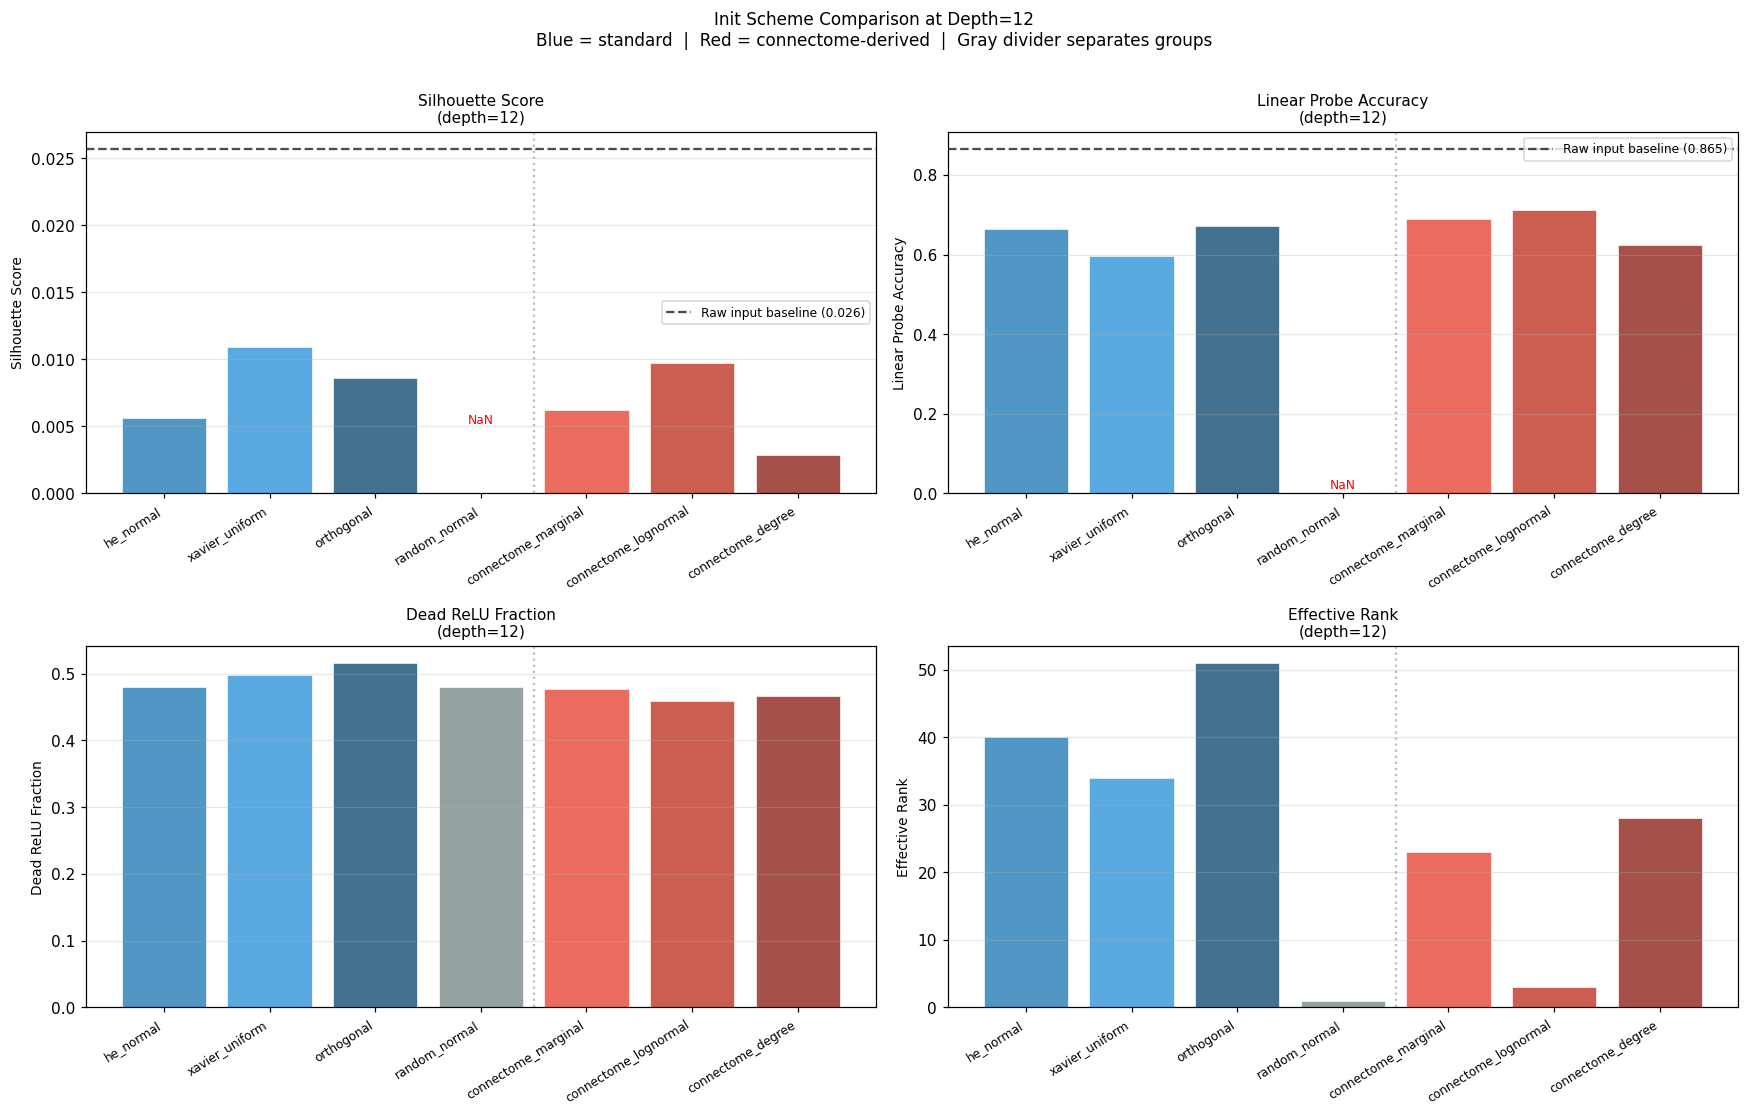

Saved c5_comparison_results.png


In [11]:
if not TORCH_AVAILABLE or not results:
    print('No results — run Cell 9 first')
else:
    all_schemes = CONFIG['standard_inits'] + CONFIG['connectome_inits']
    n_std = len(CONFIG['standard_inits'])

    metric_keys   = ['silhouette', 'linear_probe_acc', 'dead_relu_frac', 'eff_rank']
    metric_labels = ['Silhouette Score', 'Linear Probe Accuracy',
                     'Dead ReLU Fraction', 'Effective Rank']
    baselines = [score_sil_baseline, score_acc_baseline, None, None]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes_flat = axes.flatten()

    for ax, mkey, mlabel, bline in zip(axes_flat, metric_keys, metric_labels, baselines):
        vals  = [results[s][mkey] for s in all_schemes]
        bvals = [v if not np.isnan(v) else 0.0 for v in vals]
        clrs  = [COLORS_SCHEME[s] for s in all_schemes]

        ax.bar(range(len(all_schemes)), bvals, color=clrs, alpha=0.82,
               edgecolor='white', linewidth=0.5)

        # Mark NaN bars
        for i, v in enumerate(vals):
            if np.isnan(v):
                ax.text(i, 0.005, 'NaN', ha='center', va='bottom', fontsize=8, color='red')

        # Baseline line
        if bline is not None:
            ax.axhline(bline, color='black', linestyle='--', alpha=0.7,
                       label=f'Raw input baseline ({bline:.3f})')
            ax.legend(fontsize=8)

        # Divider between standard and connectome init groups
        ax.axvline(n_std - 0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)

        ax.set_xticks(range(len(all_schemes)))
        ax.set_xticklabels(all_schemes, rotation=32, ha='right', fontsize=8)
        ax.set_title(f'{mlabel}\n(depth={CONFIG["n_layers"]})', fontsize=10)
        ax.set_ylabel(mlabel, fontsize=9)
        ax.grid(alpha=0.3, axis='y')

    plt.suptitle(
        f'Init Scheme Comparison at Depth={CONFIG["n_layers"]}\n'
        'Blue = standard  |  Red = connectome-derived  |  Gray divider separates groups',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig('./outputs/c5_comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved c5_comparison_results.png')

## Cell 11 — Per-Layer Separability Curve

This plot shows how class separability decays layer-by-layer for `orthogonal` (best standard init) vs `connectome_degree` (most novel connectome init). The x-axis is layer depth; the y-axis is silhouette score.

This is the **most important diagnostic** for the thesis:
- If connectome_degree decays slower → connectome init has geometric advantage
- If connectome_degree decays faster → heavy-tail / heterogeneity hurts
- If they track together → init shape doesn't matter, only variance matters (supports the GIH theory)

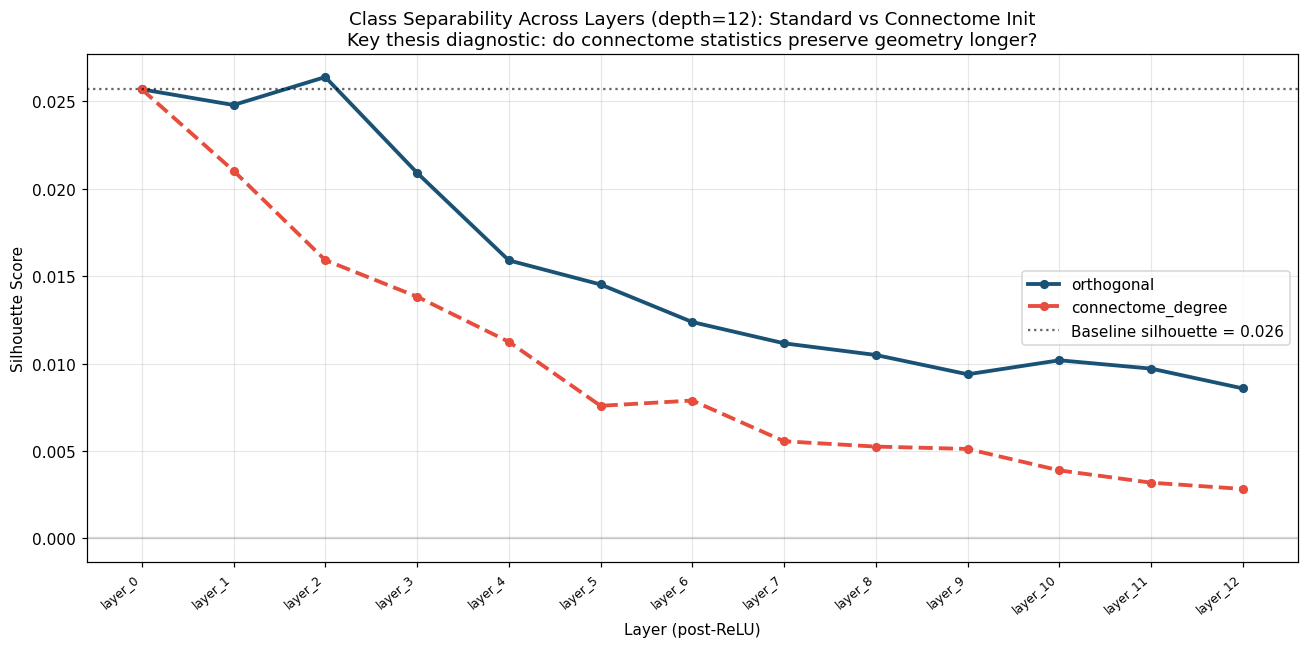

Saved c6_perlayer_separability.png


In [12]:
if not TORCH_AVAILABLE or not perlayer_results:
    print('No per-layer results — run Cell 9 first')
else:
    layer_keys = [f'layer_{i}' for i in range(CONFIG['n_layers'] + 1)]

    fig, ax = plt.subplots(figsize=(12, 6))

    for scheme, color, ls, lw_ in [
        ('orthogonal',        '#1A5276', '-',  2.5),
        ('connectome_degree', '#E74C3C', '--', 2.5),
    ]:
        ys = [perlayer_results[scheme].get(k, np.nan) for k in layer_keys]
        ax.plot(range(len(layer_keys)), ys, color=color, linestyle=ls, linewidth=lw_,
                marker='o', markersize=5, label=scheme)

    ax.axhline(score_sil_baseline, color='black', linestyle=':', alpha=0.6,
               label=f'Baseline silhouette = {score_sil_baseline:.3f}')
    ax.axhline(0, color='gray', alpha=0.3)

    ax.set_xticks(range(len(layer_keys)))
    ax.set_xticklabels(layer_keys, rotation=40, ha='right', fontsize=8)
    ax.set_title(
        f'Class Separability Across Layers (depth={CONFIG["n_layers"]}): '
        'Standard vs Connectome Init\n'
        'Key thesis diagnostic: do connectome statistics preserve geometry longer?'
    )
    ax.set_xlabel('Layer (post-ReLU)')
    ax.set_ylabel('Silhouette Score')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('./outputs/c6_perlayer_separability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved c6_perlayer_separability.png')

## Section 7 — Research Hypotheses for the Full Thesis

### What this prototype established
1. **Connectome statistics are measurably different** from null models (ER, BA) in degree distribution and rich-club structure
2. **Log-normal edge weights** have a heavier tail than Gaussian (confirmed by Q-Q plot)
3. **Connectome-derived init schemes** can be correctly variance-matched to He while preserving distinct shapes
4. **Preliminary geometry results** give a baseline for what changes at depth 12

### Hypotheses for Chapter 2–3 of the thesis

| # | Hypothesis | Falsifiable prediction |
|---|-----------|----------------------|
| **H1** | Connectome-marginal and lognormal inits behave similarly to He at depth 12 (same variance → same geometry) | Silhouette difference < 0.005 across all three | 
| **H2** | Connectome-degree init differs from He because per-neuron variance is heterogeneous | Silhouette or rank differs by > 10% from He at depths ≥ 10 |
| **H3** | Heavy-tailed init (connectome) increases Initial Guessing Bias (Francazi et al. 2024) | Class logit distribution at init is more skewed for connectome inits |
| **H4** | Connectome init effects (if any) persist through 100 training epochs | Accuracy gap at epoch 100 correlates with geometry gap at init |
| **H5** | The above effects are stronger for bio-plausible learners (Forward-Forward, Predictive Coding, DLL) than for backprop | Cross-learner comparison shows larger init × learner interaction |

### The graduate thesis arc (Topic X1)
- **Chapter 1** (this notebook, month 1–2): Connectome statistics characterization + init scheme definitions
- **Chapter 2** (month 3–5): Full experiment matrix (3 architectures × 7 inits × 3 datasets × 5 seeds)
- **Chapter 3** (month 6–7): Add IGB measurement (H3) and training dynamics (H4)
- **Chapter 4** (month 8–9): Bio-plausible learners comparison (H5) — uses PCX and DLL libraries

### Immediate next steps
1. Replace synthetic connectome with real data: `pip install allensdk`, then re-run Section 1
2. Add IGB measurement cell: measure class-prediction logits distribution at init for each scheme
3. Extend per-layer tracking to ALL 7 schemes (not just 2)
4. Add ResNet-18 alongside the MLP (torchvision's built-in, replace all `nn.Linear` init)

In [13]:
print('=' * 65)
print('PROTOTYPE SUMMARY')
print('=' * 65)

print(f'\n[1] CONNECTOME')
print(f'    Source:   {connectome_source}')
print(f'    Regions:  {N_REGIONS}  |  Edges: {N_EDGES}  |  Density: {DENSITY:.3f}')
print(f'    log(w):   mean={MU_LW:.3f}, std={SIGMA_LW:.3f}  (log-normal)')
print(f'    Hubs:     {is_hub.sum()} regions (top 10% by degree)')

print(f'\n[2] INIT SCHEMES DEFINED')
for s in CONFIG['standard_inits']:
    print(f'    [standard]   {s}')
for s in CONFIG['connectome_inits']:
    print(f'    [connectome] {s}')

if TORCH_AVAILABLE and results:
    print(f'\n[3] GEOMETRY AT DEPTH={CONFIG["n_layers"]}')
    hdr = f'  {"Scheme":28s} {"Silhouette":>12} {"LinProbe":>10} {"DeadReLU":>10} {"Rank":>6}'
    print(hdr)
    print('  ' + '-' * 68)
    for s in CONFIG['standard_inits'] + CONFIG['connectome_inits']:
        r = results[s]
        sil = f"{r['silhouette']:.4f}" if not np.isnan(r['silhouette']) else '   NaN  '
        acc = f"{r['linear_probe_acc']:.4f}" if not np.isnan(r['linear_probe_acc']) else '   NaN  '
        print(f'  {s:28s} {sil:>12} {acc:>10} {r["dead_relu_frac"]:>10.4f} {r["eff_rank"]:>6}')
    print(f'  {"baseline (raw input)":28s} {score_sil_baseline:>12.4f} {score_acc_baseline:>10.4f}')

print(f'\n[4] NEXT STEPS')
for i, step in enumerate([
    'pip install allensdk  →  re-run Section 1 with real data',
    'Extend per-layer tracking to all 7 schemes',
    'Add IGB measurement (Francazi et al. 2024)',
    'Add 100-epoch training loop — does init advantage persist?',
    'Test with Forward-Forward and PCX learners',
], 1):
    print(f'    {i}. {step}')

PROTOTYPE SUMMARY

[1] CONNECTOME
    Source:   allen_sdk
    Regions:  157  |  Edges: 7102  |  Density: 0.290
    log(w):   mean=-2.679, std=1.353  (log-normal)
    Hubs:     17 regions (top 10% by degree)

[2] INIT SCHEMES DEFINED
    [standard]   he_normal
    [standard]   xavier_uniform
    [standard]   orthogonal
    [standard]   random_normal
    [connectome] connectome_marginal
    [connectome] connectome_lognormal
    [connectome] connectome_degree

[3] GEOMETRY AT DEPTH=12
  Scheme                         Silhouette   LinProbe   DeadReLU   Rank
  --------------------------------------------------------------------
  he_normal                          0.0056     0.6650     0.4795     40
  xavier_uniform                     0.0109     0.5950     0.4977     34
  orthogonal                         0.0086     0.6725     0.5157     51
  random_normal                       NaN        NaN       0.4795      1
  connectome_marginal                0.0062     0.6900     0.4763     23
  co